<a href="https://colab.research.google.com/github/Gada-23/Ambo-University-Online-Exam-System/blob/main/Fake_Currency_Detection_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Denomination dataset
denomination_path = '/content/drive/MyDrive/ethiopian_birr_dataset'

# Authentication dataset
authentication_path = '/content/drive/MyDrive/ethiopian_birr_two_classes'

# Verify folder structure
import os

print("Denomination dataset folders:", os.listdir(denomination_path))
print("Authentication dataset folders:", os.listdir(authentication_path))


Denomination dataset folders: ['train', 'val']
Authentication dataset folders: ['val', 'test', 'train']


In [ ]:
# Denomination train folders
print("Denomination train subfolders:", os.listdir(os.path.join(denomination_path,'train')))

# Authentication train folders
print("Authentication train subfolders:", os.listdir(os.path.join(authentication_path,'train')))


Denomination train subfolders: ['50birr', '200birr', '10birr', '100birr', '5birr']
Authentication train subfolders: ['fake_100', 'fake_200', 'real_100', 'real_200']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
denom_train_path = '/content/drive/MyDrive/ethiopian_birr_dataset/train'
denom_val_path = '/content/drive/MyDrive/ethiopian_birr_dataset/val'

train_datagen_denom = ImageDataGenerator(
    rescale=1./255,           # normalization
    rotation_range=20,         # augmentation
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen_denom = ImageDataGenerator(rescale=1./255)

train_generator_denom = train_datagen_denom.flow_from_directory(
    denom_train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'   # one-hot encoding
)

val_generator_denom = val_datagen_denom.flow_from_directory(
    denom_val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


Found 1035 images belonging to 5 classes.
Found 295 images belonging to 5 classes.


In [ ]:
auth_train_path = '/content/drive/MyDrive/ethiopian_birr_two_classes/train'
auth_val_path = '/content/drive/MyDrive/ethiopian_birr_two_classes/val'

train_datagen_auth = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen_auth = ImageDataGenerator(rescale=1./255)

train_generator_auth = train_datagen_auth.flow_from_directory(
    auth_train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator_auth = val_datagen_auth.flow_from_directory(
    auth_val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


Found 2800 images belonging to 4 classes.
Found 440 images belonging to 4 classes.


In [ ]:
# Denomination class labels
print("Denomination classes:", train_generator_denom.class_indices)

# Authentication class labels
print("Authentication classes:", train_generator_auth.class_indices)


Denomination classes: {'100birr': 0, '10birr': 1, '200birr': 2, '50birr': 3, '5birr': 4}
Authentication classes: {'fake_100': 0, 'fake_200': 1, 'real_100': 2, 'real_200': 3}


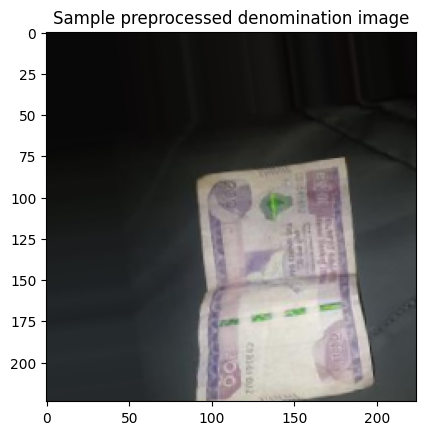

In [ ]:
import matplotlib.pyplot as plt
x_batch, y_batch = next(train_generator_denom)
plt.imshow(x_batch[0])
plt.title("Sample preprocessed denomination image")
plt.show()


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam


**Denomination model**

In [ ]:
# Base MobileNetV2 model (feature extractor)
base_model_denom = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Custom classification head
x = base_model_denom.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions_denom = Dense(5, activation='softmax')(x)  # 5 classes: 5,10,50,100,200

# Final model
denomination_model = Model(inputs=base_model_denom.input, outputs=predictions_denom)

# Compile the model
denomination_model.compile(optimizer=Adam(learning_rate=0.0001),
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

# Summary
denomination_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 2,388,485 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

**Authentication Model**

In [ ]:
# Base MobileNetV2 model
base_model_auth = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Custom classification head
x = base_model_auth.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions_auth = Dense(4, activation='softmax')(x)  # 4 classes: real_100, real_200, fake_100, fake_200

# Final model
authentication_model = Model(inputs=base_model_auth.input, outputs=predictions_auth)

# Compile the model
authentication_model.compile(optimizer=Adam(learning_rate=0.0001),
                             loss='categorical_crossentropy',
                             metrics=['accuracy'])

# Summary
authentication_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 2,388,356 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

**Train Denomination Model**

In [ ]:
# Train Denomination Model
epochs_denom = 30  # adjust if needed
history_denom = denomination_model.fit(
    train_generator_denom,  # preprocessed, normalized, one-hot encoded
    validation_data=val_generator_denom,
    epochs=epochs_denom
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 410s 11s/step - accuracy: 0.4705 - loss: 1.3666 - val_accuracy: 0.6712 - val_loss: 0.8883
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 248s 7s/step - accuracy: 0.9161 - loss: 0.3433 - val_accuracy: 0.6407 - val_loss: 0.9563
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 251s 8s/step - accuracy: 0.9676 - loss: 0.1190 - val_accuracy: 0.6847 - val_loss: 0.9861
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 251s 8s/step - accuracy: 0.9848 - loss: 0.0559 - val_accuracy: 0.6746 - val_loss: 1.3086
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.9945 - loss: 0.0356 - val_accuracy: 0.6983 - val_loss: 1.0136
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 270s 8s/step - accuracy: 0.9967 - loss: 0.0254 - val_accuracy: 0.7254 - val_loss: 0.8115
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 251s 8s/step - accuracy: 0.9979 - loss: 0.0167 - val_accuracy: 0.7186 - val_loss: 0.9369
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 254s 8s/step - accuracy: 0.9965 - loss: 0.0149 - val_accuracy: 0.7356 - 

**Train Authentication Model**

In [ ]:
# Train Authentication Model
epochs_auth = 30
history_auth = authentication_model.fit(
    train_generator_auth,  # preprocessed, normalized, one-hot encoded
    validation_data=val_generator_auth,
    epochs=epochs_auth
)


Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1352s 15s/step - accuracy: 0.8045 - loss: 0.5588 - val_accuracy: 0.5568 - val_loss: 1.0976
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 807s 9s/step - accuracy: 0.9913 - loss: 0.0289 - val_accuracy: 0.6068 - val_loss: 0.9320
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 804s 9s/step - accuracy: 0.9927 - loss: 0.0190 - val_accuracy: 0.7250 - val_loss: 0.7568
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 800s 9s/step - accuracy: 0.9925 - loss: 0.0235 - val_accuracy: 0.6795 - val_loss: 0.7689
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 794s 9s/step - accuracy: 0.9973 - loss: 0.0073 - val_accuracy: 0.7932 - val_loss: 0.4873
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 802s 9s/step - accuracy: 0.9979 - loss: 0.0091 - val_accuracy: 0.8455 - val_loss: 0.3716
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 791s 9s/step - accuracy: 0.9977 - loss: 0.0073 - val_accuracy: 0.8773 - val_loss: 0.3216
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 798s 9s/step - accuracy: 0.9976 - loss: 0.0083 - val_accuracy: 0.8227 -

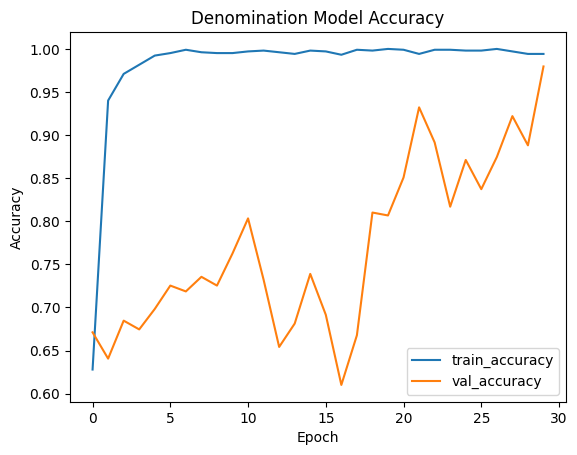

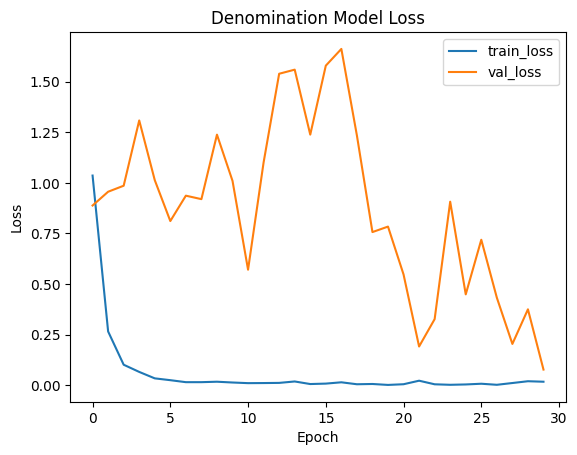

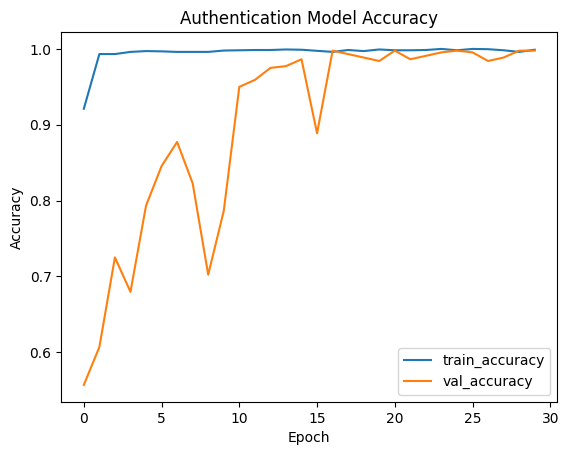

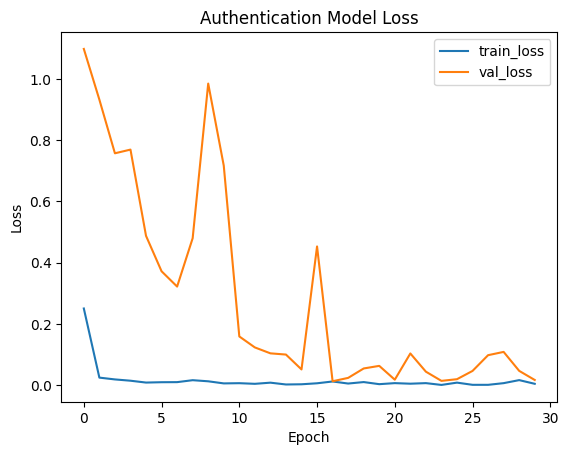

In [ ]:
import matplotlib.pyplot as plt

# Denomination Model
plt.plot(history_denom.history['accuracy'], label='train_accuracy')
plt.plot(history_denom.history['val_accuracy'], label='val_accuracy')
plt.title("Denomination Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_denom.history['loss'], label='train_loss')
plt.plot(history_denom.history['val_loss'], label='val_loss')
plt.title("Denomination Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Authentication Model
plt.plot(history_auth.history['accuracy'], label='train_accuracy')
plt.plot(history_auth.history['val_accuracy'], label='val_accuracy')
plt.title("Authentication Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_auth.history['loss'], label='train_loss')
plt.plot(history_auth.history['val_loss'], label='val_loss')
plt.title("Authentication Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
val_generator_denom = val_datagen_denom.flow_from_directory(
    denom_val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # 🔴 VERY IMPORTANT
)

val_generator_auth = val_datagen_auth.flow_from_directory(
    auth_val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False   # 🔴 VERY IMPORTANT
)


NameError: name 'val_datagen_denom' is not defined

**Denomination Model Confusion Matrix**


In [ ]:
# Reset generator to avoid shuffled order
val_generator_denom.reset()

# Get predictions
y_pred_denom = denomination_model.predict(val_generator_denom)
y_pred_denom_classes = np.argmax(y_pred_denom, axis=1)

# True labels
y_true_denom = val_generator_denom.classes

# Class names
class_names_denom = list(val_generator_denom.class_indices.keys())


10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


<Figure size 800x600 with 0 Axes>

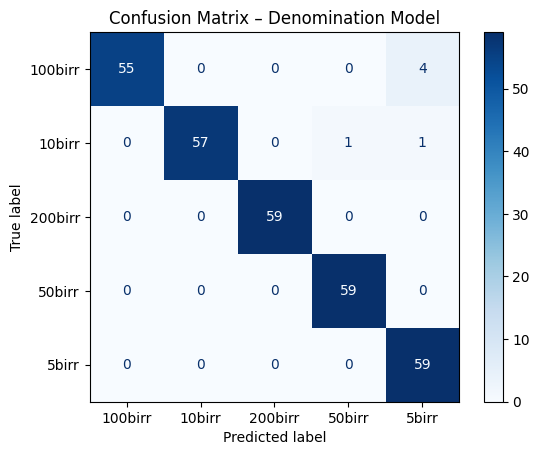

In [ ]:
cm_denom = confusion_matrix(y_true_denom, y_pred_denom_classes)

disp_denom = ConfusionMatrixDisplay(
    confusion_matrix=cm_denom,
    display_labels=class_names_denom
)

plt.figure(figsize=(8,6))
disp_denom.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix – Denomination Model")
plt.show()


**Authentication Model Confusion Matrix**

In [ ]:
# Reset generator
val_generator_auth.reset()

# Get predictions
y_pred_auth = authentication_model.predict(val_generator_auth)
y_pred_auth_classes = np.argmax(y_pred_auth, axis=1)

# True labels
y_true_auth = val_generator_auth.classes

# Class names
class_names_auth = list(val_generator_auth.class_indices.keys())


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step


<Figure size 800x600 with 0 Axes>

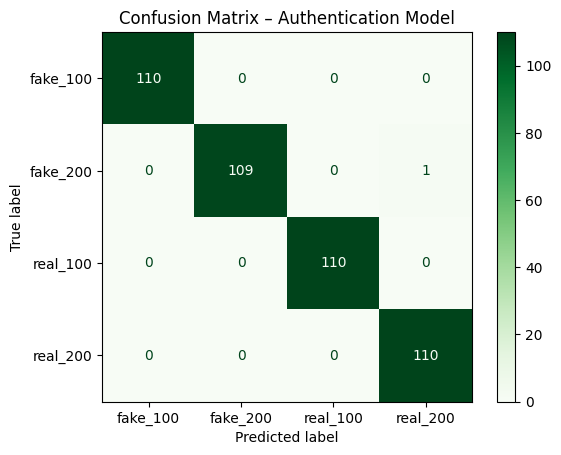

In [ ]:
cm_auth = confusion_matrix(y_true_auth, y_pred_auth_classes)

disp_auth = ConfusionMatrixDisplay(
    confusion_matrix=cm_auth,
    display_labels=class_names_auth
)

plt.figure(figsize=(8,6))
disp_auth.plot(cmap=plt.cm.Greens, values_format='d')
plt.title("Confusion Matrix – Authentication Model")
plt.show()


In [ ]:
denomination_model.save('/content/drive/MyDrive/my_model/denomination_model.h5')
authentication_model.save('/content/drive/MyDrive/my_model/authentication_model.h5')


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

denomination_model = load_model(
    '/content/drive/MyDrive/my_model/denomination_model.h5'
)

authentication_model = load_model(
    '/content/drive/MyDrive/my_model/authentication_model.h5'
)

print("✅ Models loaded successfully from Google Drive")


✅ Models loaded successfully from Google Drive


In [ ]:
from google.colab import files
uploaded = files.upload()


KeyboardInterrupt: 

In [ ]:
import cv2
import numpy as np

IMG_SIZE = 224  # MobileNetV2 input size

img_path = list(uploaded.keys())[0]
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0
img = np.expand_dims(img, axis=0)


In [ ]:
denomination_classes = ['100birr', '10birr', '200birr', '50birr', '5birr']

den_pred = denomination_model.predict(img)
den_class = denomination_classes[np.argmax(den_pred)]

print("Predicted Denomination:", den_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Denomination: 10birr


In [ ]:
auth_classes = ['fake_100', 'fake_200','real_100', 'real_200']

auth_pred = authentication_model.predict(img)
auth_class = auth_classes[np.argmax(auth_pred)]

print("Authentication Result:", auth_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Authentication Result: fake_100


In [ ]:
denomination_model.save(
    '/content/drive/MyDrive/project/models/denomination_model/final_model.h5'
)


In [ ]:
authentication_model.save(
    '/content/drive/MyDrive/project/models/authenticity_model/final_model.h5'
)


In [ ]:
# Denomination model
denomination_model.save(
    '/content/drive/MyDrive/project/models/denomination_model/final_model.keras'
)

# Authentication model
authentication_model.save(
    '/content/drive/MyDrive/project/models/authenticity_model/final_model.keras'
)


In [ ]:
# Denomination model
denom_model.export('/content/drive/MyDrive/project/models/denomination_model/final_model_savedmodel')

# Authentication model
auth_model.export('/content/drive/MyDrive/project/models/authenticity_model/final_model_savedmodel')


Saved artifact at '/content/drive/MyDrive/project/models/denomination_model/final_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')]
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134084860337168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860335248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860336016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860337360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860336592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860338704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860335440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860332944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860337744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134084860335632:

In [4]:
from tensorflow.keras.models import load_model
# Load your trained .h5 model (from Colab)
denom_model = load_model('/content/drive/MyDrive/project/models/denomination_model/final_model.h5')
auth_model = load_model('/content/drive/MyDrive/project/models/authenticity_model/final_model.h5')


In [ ]:
denom_model.save('final_model_legacy.h5')
auth_model.save('final_model_legacy.h5')


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
